**# **Iterative Workflow Using LangGraph**


In [1]:
import os
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

load_dotenv()

d:\AgenticAI-LangGraph-projects\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# Initialize Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)

In [3]:
# 1. Define State
class EditorState(TypedDict):
    topic: str
    draft: str
    feedback: str
    loop_count: int
    status: str

# 2. Define Structured Output for Editor
class EditorAction(BaseModel):
    feedback: str = Field(..., description="Detailed feedback on the draft.")
    status: Literal["approved", "rejected"] = Field(..., description="Whether the draft is structurally perfect.")

editor_llm = llm.with_structured_output(EditorAction)

In [4]:
# 3. Define Nodes

def copywriter(state: EditorState) -> EditorState:
    print(f"---COPYWRITER: Drafting (Attempt {state['loop_count'] + 1})---")
    if state["draft"] == "":
        prompt = f"Write a short, engaging, 2-paragraph article about: {state['topic']}"
    else:
        prompt = f"Revise this article about {state['topic']}. \n\nCurrent Draft:\n{state['draft']}\n\nEditor Feedback:\n{state['feedback']}"
    
    result = llm.invoke(prompt)
    return {
        "draft": result.content,
        "loop_count": state["loop_count"] + 1
    }

def editor(state: EditorState) -> EditorState:
    print("---EDITOR: Reviewing Draft---")
    prompt = f"""Review this short article. 
    Criteria:
    1. Must be extremely concise.
    2. No passive voice.
    3. Must have an exciting tone.
    Draft:
    {state['draft']} 
    """
    result = editor_llm.invoke(prompt)
    print(f"-> Editor Status: {result.status.upper()}")
    print(f"-> Editor Feedback: {result.feedback}\n")
    return {
        "feedback": result.feedback,
        "status": result.status
    }

In [5]:
# 4. Define Loop Condition
def route_decision(state: EditorState) -> str:
    """Decide if we should review again or finish."""
    if state["status"] == "approved":
        return "END"
    if state["loop_count"] >= 3: # Enforce a 3-loop maximum
        print("-> MAXIMUM ATTEMPTS REACHED. FORWARDING TO END.")
        return "END"
    
    return "copywriter"

In [6]:
# 5. Build Graph
graph = StateGraph(EditorState)

graph.add_node("copywriter", copywriter)
graph.add_node("editor", editor)

# Edge from START to copywriter
graph.add_edge(START, "copywriter")
# Copywriter always sends draft to editor
graph.add_edge("copywriter", "editor")

# Conditionally loop back to copywriter OR end
graph.add_conditional_edges(
    source="editor",
    path=route_decision,
    path_map={
        "copywriter": "copywriter",
        "END": END
    }
)

workflow = graph.compile()

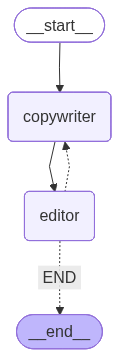

In [7]:
workflow

In [8]:
# 6. Test the Iterative Workflow
initial_state = {
    "topic": "The future of Artificial Intelligence in space exploration",
    "draft": "",
    "feedback": "",
    "loop_count": 0,
    "status": ""
}

final_state = workflow.invoke(initial_state)
print("\n\n=== FINAL APPROVED DRAFT ===\n")
print(final_state['draft'])

---COPYWRITER: Drafting (Attempt 1)---
---EDITOR: Reviewing Draft---
-> Editor Status: APPROVED
-> Editor Feedback: The draft meets the criteria of being concise, using active voice, and having an exciting tone. However, some sentences are wordy and could be shortened for better impact. The use of transitional phrases and words, such as 'For example' and 'Furthermore', could be reduced to make the text even more concise. The language is engaging, and the examples provided are relevant and interesting. To make it perfect, consider using more dynamic verbs and varying sentence structure to create a sense of rhythm and flow.



=== FINAL APPROVED DRAFT ===

As space agencies and private companies continue to push the boundaries of space exploration, Artificial Intelligence (AI) is poised to play a vital role in the next great leap for humanity. The future of AI in space exploration is exciting and full of possibilities, from autonomous spacecraft that can navigate and make decisions witho